<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day10_practice3_%ED%95%9C%EA%B3%84%EC%99%80_%EB%8F%99%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 사전학습 모델의 한계 - 커스텀

In [1]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.8 MB/s eta 0:00:00


In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Install NanumGothic font
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 86 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,132 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tt

In [3]:
from ultralytics import YOLO
from PIL import Image, ImageEnhance, ImageFilter
import urllib.request, os, time
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:
BUS_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
if not os.path.exists("bus.jpg"):
  urllib.request.urlretrieve(BUS_URL, "bus.jpg")
  print("bus.jpg 다운로드 완료 (재실행 시 재사용)")

bus.jpg 다운로드 완료 (재실행 시 재사용)


In [5]:
model = YOLO("yolo11m.pt")      # 모델 로드

In [9]:
# 셀 1. COCO에 도로 위험은 없다
coco_classes = list(model.names.values())
print(f"COCO 클래스 {len(coco_classes)}종 중에서 찾아보면:")
for word in ["pothole", "crack", "manhole", "road"]:
  found = [c for c in coco_classes if word in c.lower()]
  print(f" '{word}' 포함 클래스: {found if found else '없음'}")
print("\n 80종 전체:", coco_classes)

COCO 클래스 80종 중에서 찾아보면:
 'pothole' 포함 클래스: 없음
 'crack' 포함 클래스: 없음
 'manhole' 포함 클래스: 없음
 'road' 포함 클래스: 없음

 80종 전체: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']



[열화 실험] conf=0.25 기준
  원본           -> 5개 [{0.93, 'bus'}, {0.92, 'person'}, {0.91, 'person'}, {0.89, 'person'}, {0.79, 'person'}]
  어둡게(x0.3)    -> 6개 [{0.92, 'person'}, {0.89, 'person'}, {0.88, 'person'}, {0.84, 'bus'}, {0.74, 'person'}, {0.31, 'tie'}]
  축소(160px)    -> 4개 [{0.88, 'person'}, {0.87, 'bus'}, {0.87, 'person'}, {0.82, 'person'}]
  블러(반경5)      -> 6개 [{0.9, 'person'}, {0.89, 'bus'}, {0.88, 'person'}, {0.86, 'person'}, {0.29, 'dog'}, {0.27, 'person'}]


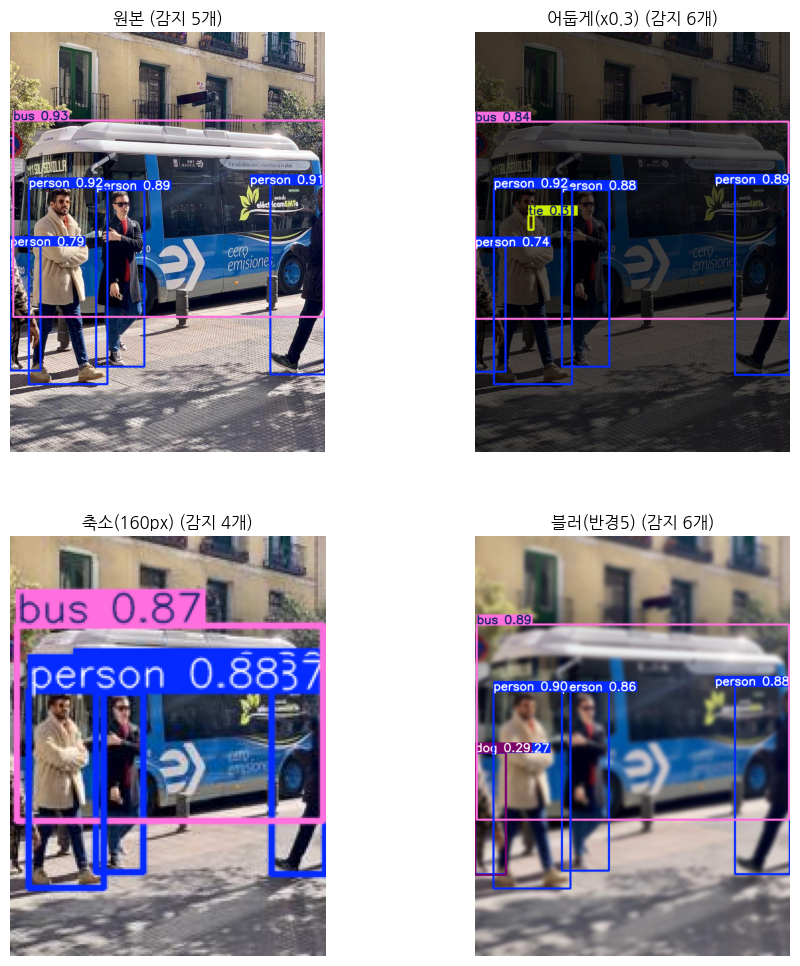

In [11]:
# 셀 2. 강건성 실험 - 현실의 사진은 깨끗하지 않다
# 신고 앱의 현실: 밤길, 흔들린 손, 저사양 폰
# 같은 사진을 3가지로 열화시켜(사진의 화질이나 상태를 나쁘게 만든다) 감지가 어떻게 무너지는지 실측
src = Image.open("bus.jpg")
variants = {
    "원본": src,
    "어둡게(x0.3)": ImageEnhance.Brightness(src).enhance(0.3), # 밝기 조절, 0.3 = 원본의 30% (어둡게)
    "축소(160px)": src.resize((160, int(160 * src.height / src.width))), # 저해상
    "블러(반경5)": src.filter(ImageFilter.GaussianBlur(5)),           # 손떨림 묘사
}
print("\n[열화 실험] conf=0.25 기준")

fig, axes = plt.subplots(2, 2, figsize=(11,12))
axes = axes.ravel()   # 1차원(4개)으로 펴서 순서대로
for yi, (name, im) in enumerate(variants.items()):
  path = f"variant_{yi}.jpg"
  im.save(path)
  r = model(path, verbose=False)[0]
  dets = [{r.names[int(b.cls)], round(float(b.conf), 2)} for b in r.boxes]
  print(f"  {name:12s} -> {len(dets)}개 {dets}")

  axes[yi].imshow(r.plot()[:, :, ::-1])
  axes[yi].set_title(f"{name} (감지 {len(dets)}개)")
  axes[yi].axis("off")
  os.remove(path)